# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

#### The Dataset

- Source: A Portuguese bank's contact center, covering 17 campaigns (May 2008 – Nov 2010)
- Total contacts: 79,354
- Successes (subscribed): 5,289 out of 79,354 (8%)
- Target variable: Binary — did the client subscribe the deposit? (yes / no)

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [5]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
# Check for missing values
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [7]:
# Check for 'unknown' values across categorical columns
categorical_cols = df.select_dtypes(include='object').columns
df[categorical_cols].apply(lambda col: (col == 'unknown').sum()).rename('unknown_count')

job             330
marital          80
education      1731
default        8597
housing         990
loan            990
contact           0
month             0
day_of_week       0
poutcome          0
y                 0
Name: unknown_count, dtype: int64

#### Summary of Findings:

- No true NaN missing values. All 41,188 rows have non-null values in every column.
- Implicit missing values ('unknown' strings):
    - default: 8,597
    - education: 1,731
    - housing: 990
    - loan: 990
    - job: 330
    - marital: 80
- All 10 object columns (categoricals) need encoding
- Target y ('yes'/'no') must be converted to binary (1/0)
- pdays = 999 means "never contacted" and is not a real numeric value, may need a separate boolean flag
    
    

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

**Business Objective:**

Creating a model that can predict which customers are most likely to say "yes" during a phone campaign that sell term deposit products. The model can help the bank focus its calls on those customers, save time and money, while avoid bothering customers who are eunlikeely to be interested.

**Business Success Criteria:**

The analysis is considered successful if it produces clear, actionable recommendation in the form of a Classifier that lets the bank contact fewer clients without losing subscribers

**Resources:**

A dataset of 41,188 contacts, 20 features, UCI dataset (bank-additional-full.csv)

**Requirements:**

- No additional data collection is planned.
- Results must be delivered as a Jupyter notebook with accompanying README summary.
- A comparison between 4 classifiers  (k-nearest neighbors, logistic regression, decision trees, and support vector machines)
- Findings must be in plain-langauage recommendations for a non-technical audience.

**Data Mining Goal:**

Build a Binary classification comparing KNN, Logistic Regression, Decision Tree, SVM

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

**Bank client features used:** `age`, `job`, `marital`, `education`, `default`, `housing`, `loan`

- `age` is already numeric. No transformation needed.
- Categorical columns are one-hot encoded with `pd.get_dummies` (dropping the first category to avoid multicollinearity)
- Target `y` is mapped from `'yes'`/`'no'` to `1`/`0`

In [8]:
# Select only bank client information features
bank_features = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']

X = df[bank_features].copy()
y = df['y'].map({'yes': 1, 'no': 0})

# One-hot encode categorical columns
X = pd.get_dummies(X, columns=['job', 'marital', 'education', 'default', 'housing', 'loan'], drop_first=True)

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())
X.head()

Feature matrix shape: (41188, 28)
Target distribution:
 y
0    36548
1     4640
Name: count, dtype: int64


,age,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_unknown,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes
0,56,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,57,False,False,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
2,37,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,40,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,56,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)
print(f"\nTrain target distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True).round(3)}")

Training set size: (32950, 28)
Test set size:     (8238, 28)

Train target distribution:
y
0    0.887
1    0.113
Name: proportion, dtype: float64

Test target distribution:
y
0    0.887
1    0.113
Name: proportion, dtype: float64


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [10]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

baseline_train_acc = dummy.score(X_train, y_train)
baseline_test_acc  = dummy.score(X_test, y_test)

print(f"Baseline Train Accuracy: {baseline_train_acc:.4f}")
print(f"Baseline Test Accuracy:  {baseline_test_acc:.4f}")
print("Any useful model must score above {:.2f}% test accuracy.".format(baseline_test_acc * 100))

Baseline Train Accuracy: 0.8873
Baseline Test Accuracy:  0.8874
Any useful model must score above 88.74% test accuracy.


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import time

# Scale features — important for Logistic Regression convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Fit Logistic Regression
start = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
train_time = time.time() - start

lr_train_acc = lr.score(X_train_scaled, y_train)
lr_test_acc  = lr.score(X_test_scaled, y_test)

print(f"Train Time:      {train_time:.4f}s")
print(f"Train Accuracy:  {lr_train_acc:.4f}")
print(f"Test Accuracy:   {lr_test_acc:.4f}")

Train Time:      0.0606s
Train Accuracy:  0.8873
Test Accuracy:   0.8874


### Problem 9: Score the Model

What is the accuracy of your model?

=== Logistic Regression Scores ===
Baseline Test Accuracy:  0.8874
LR Train Accuracy:       0.8873
LR Test Accuracy:        0.8874


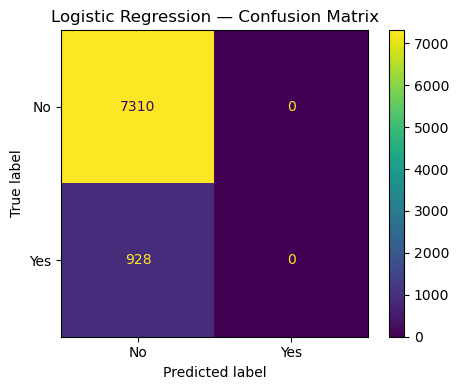

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("=== Logistic Regression Scores ===")
print(f"Baseline Test Accuracy:  {baseline_test_acc:.4f}")
print(f"LR Train Accuracy:       {lr_train_acc:.4f}")
print(f"LR Test Accuracy:        {lr_test_acc:.4f}")


# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(lr, X_test_scaled, y_test, display_labels=['No', 'Yes'], ax=ax)
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

#### Summary of Findings:

The Logistic Regression achieves 88.74% test accuracy which is identical to the 88.7% from the baseline (always predict "no").

The model predicted "yes" exactly zero times. It learned that blindly predicting "no" for every customer yields a high accuracy score due to the class imbalance (~89% of contacts do not subscribe).

The bank client demographic features alone (age, job, marital, education, default, housing, loan) do not carry enough signal to distinguish subscribers from non-subscribers.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import time

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN':                 KNeighborsClassifier(),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'SVM':                 SVC(random_state=42),
}

results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start

    train_acc = model.score(X_train_scaled, y_train)
    test_acc  = model.score(X_test_scaled,  y_test)

    results.append({
        'Model':          name,
        'Train Time (s)': round(train_time, 4),
        'Train Accuracy': round(train_acc,  4),
        'Test Accuracy':  round(test_acc,   4),
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df

,Train Time (s),Train Accuracy,Test Accuracy
Model,,,
Logistic Regression,0.0459,0.8873,0.8874
KNN,0.0070,0.8920,0.8799
Decision Tree,0.0742,0.9171,0.8639
SVM,45.8653,0.8876,0.8875


#### Summary of Findings:

- All four models are clustering around the 88% baseline. This is confirming that the demographic features alone are insufficient.
- Decision Tree is overfitting. 91.7% train vs 86.4% test, the biggest gap of the group.
- SVM is the slowest by far (48s vs <0.9s for the others) for essentially the same result as Logistic Regression.
- KNN is the fastest to train.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

**Expanding the Feature Set**

In [14]:
# Expanded feature set: bank client info + campaign contact info (excluding duration)
features = [
    'age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome'
]

data = df[features].copy()
y = df['y'].map({'yes': 1, 'no': 0})

# Engineer pdays: 999 means "never previously contacted" — encode as a flag
data['contacted_before'] = (data['pdays'] != 999).astype(int)
data['pdays'] = data['pdays'].replace(999, 0)

# One-hot encode all categoricals; 'unknown' becomes its own dummy column
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
            'contact', 'month', 'day_of_week', 'poutcome']
X = pd.get_dummies(data, columns=cat_cols, drop_first=True)

print("Feature matrix shape:", X.shape)
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"\nunknown-related columns retained:")
print([c for c in X.columns if 'unknown' in c])
X.head()

Feature matrix shape: (41188, 48)

Target distribution:
y
0    36548
1     4640
Name: count, dtype: int64

unknown-related columns retained:
['job_unknown', 'marital_unknown', 'education_unknown', 'default_unknown', 'housing_unknown', 'loan_unknown']


,age,campaign,pdays,previous,contacted_before,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,1,0,0,0,False,False,True,False,False,...,True,False,False,False,True,False,False,False,True,False
1,57,1,0,0,0,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
2,37,1,0,0,0,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
3,40,1,0,0,0,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
4,56,1,0,0,0,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False


In [16]:
## Split the data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)
print(f"\nTrain target distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True).round(3)}")

## Baseline Model

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

baseline_train_acc = dummy.score(X_train, y_train)
baseline_test_acc  = dummy.score(X_test, y_test)

print(f"Baseline Train Accuracy: {baseline_train_acc:.4f}")
print(f"Baseline Test Accuracy:  {baseline_test_acc:.4f}")
print("Any useful model must score above {:.2f}% test accuracy.".format(baseline_test_acc * 100))

Training set size: (32950, 48)
Test set size:     (8238, 48)

Train target distribution:
y
0    0.887
1    0.113
Name: proportion, dtype: float64

Test target distribution:
y
0    0.887
1    0.113
Name: proportion, dtype: float64
Baseline Train Accuracy: 0.8873
Baseline Test Accuracy:  0.8874
Any useful model must score above 88.74% test accuracy.


Train Time:      0.0696s
Train Accuracy:  0.8975
Test Accuracy:   0.8979
=== Logistic Regression Scores ===
Baseline Test Accuracy:  0.8874
LR Train Accuracy:       0.8975
LR Test Accuracy:        0.8979


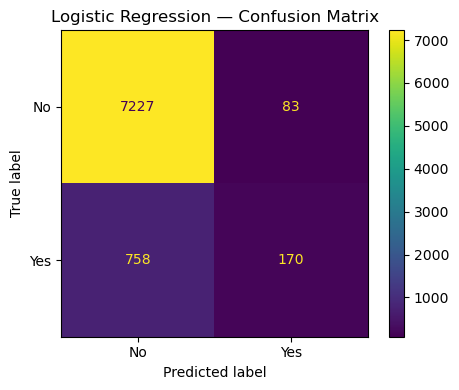

In [20]:
## Simple Model

# Scale features — important for Logistic Regression convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Fit Logistic Regression
start = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
train_time = time.time() - start

lr_train_acc = lr.score(X_train_scaled, y_train)
lr_test_acc  = lr.score(X_test_scaled, y_test)

print(f"Train Time:      {train_time:.4f}s")
print(f"Train Accuracy:  {lr_train_acc:.4f}")
print(f"Test Accuracy:   {lr_test_acc:.4f}")

## Score the Simple Model

print("=== Logistic Regression Scores ===")
print(f"Baseline Test Accuracy:  {baseline_test_acc:.4f}")
print(f"LR Train Accuracy:       {lr_train_acc:.4f}")
print(f"LR Test Accuracy:        {lr_test_acc:.4f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(lr, X_test_scaled, y_test, display_labels=['No', 'Yes'], ax=ax)
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

#### Summary of Findings:

The Logistic Regression with the expanded features achieves 89.79% test accuracy which is higher than the 88.7% from the baseline (always predict "no").

In [21]:
## Model Comparison

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN':                 KNeighborsClassifier(),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'SVM':                 SVC(random_state=42),
}

results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start

    train_acc = model.score(X_train_scaled, y_train)
    test_acc  = model.score(X_test_scaled,  y_test)

    results.append({
        'Model':          name,
        'Train Time (s)': round(train_time, 4),
        'Train Accuracy': round(train_acc,  4),
        'Test Accuracy':  round(test_acc,   4),
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df

,Train Time (s),Train Accuracy,Test Accuracy
Model,,,
Logistic Regression,0.1012,0.8975,0.8979
KNN,0.0141,0.9098,0.8915
Decision Tree,0.1883,0.9933,0.8331
SVM,135.1237,0.9072,0.8990


#### Summary of Findings:

- Three of the 4 models are clustering around the 89% Accuracy. The exception is Decision Tree with 83% Accuracy.
- Decision Tree is overfitting. 99.33% train vs 83.31% test, the biggest gap of the group.
- SVM is the slowest by far (135s vs <0.18s for the others) for essentially the same result as Logistic Regression.
- KNN is the fastest to train.

In [22]:
## Tuning and Grid Search

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

param_grids = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=42),
        {
            # C controls regularization strength — smaller C = more regularization.
            # We test a wide log-scale range (0.01 to 100) to find the right balance
            # between underfitting (too small) and overfitting (too large).
            'C': [0.01, 0.1, 1, 10, 100]
        }
    ),
    'KNN': (
        KNeighborsClassifier(),
        {
            # n_neighbors: small values (3, 5) capture local patterns but risk noise;
            # larger values (21, 51) smooth out noise but may miss local structure.
            # We test a range from very local to very broad neighborhoods.
            'n_neighbors': [3, 5, 11, 21, 51],
            # weights: 'uniform' treats all neighbors equally;
            # 'distance' gives closer neighbors more influence
            'weights': ['uniform', 'distance']
        }
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42),
        {
            # max_depth: None allows a fully grown tree.
            # We test shallow (3, 5) to deep (10) depths to find the right complexity.
            'max_depth': [3, 5, 10, None],
            # min_samples_split: minimum samples needed to split a node.
            # Higher values prevent the tree from learning noise in small subgroups.
            'min_samples_split': [2, 5, 10]
        }
    ),
    'SVM': (
        SVC(random_state=42),
        {
            # C controls the margin vs misclassification trade-off.
            # Grid is intentionally small (only 3 values) because SVM is very slow
            # to train on this dataset (~130s per fit). Even so, grid search took ~432s.
            'C': [0.1, 1, 10]
        }
    ),
}

improved_results = []
for name, (model, params) in param_grids.items():
    gs = GridSearchCV(model, params, cv=5, scoring='roc_auc', n_jobs=-1)
    start = time.time()
    gs.fit(X_train_scaled, y_train)
    train_time = time.time() - start

    best = gs.best_estimator_
    train_acc = best.score(X_train_scaled, y_train)
    test_acc  = best.score(X_test_scaled,  y_test)

    if hasattr(best, 'predict_proba'):
        test_auc = roc_auc_score(y_test, best.predict_proba(X_test_scaled)[:, 1])
    else:
        test_auc = roc_auc_score(y_test, best.decision_function(X_test_scaled))

    improved_results.append({
        'Model':          name,
        'Best Params':    gs.best_params_,
        'Train Time (s)': round(train_time, 2),
        'Train Accuracy': round(train_acc,  4),
        'Test Accuracy':  round(test_acc,   4),
        'Test AUC':       round(test_auc,   4),
    })

improved_df = pd.DataFrame(improved_results).set_index('Model')
improved_df

Exception ignored in: <function ResourceTracker.__del__ at 0x10b6edb20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x108dcdb20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


,Best Params,Train Time (s),Train Accuracy,Test Accuracy,Test AUC
Model,,,,,
Logistic Regression,{'C': 0.01},11.45,0.8972,0.8982,0.7647
KNN,"{'n_neighbors': 51, 'weights': 'uniform'}",14.22,0.8984,0.8994,0.7391
Decision Tree,"{'max_depth': 10, 'min_samples_split': 10}",3.31,0.9077,0.8945,0.7361
SVM,{'C': 0.1},424.68,0.8975,0.8969,0.7022


Exception ignored in: <function ResourceTracker.__del__ at 0x10e671b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1033a1b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10e391b20>
Traceback (most recent call last

##### Questions